In [2]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN


from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
code = 'ConceptDistance'

from pathlib import Path

d_dir = Path('/archive/vision/beery/animal_reid/datasets/elephants_zooniverse')
dict_dir = Path(__file__).parent.parent / 'data_processing/data/out_apr2/image_dictonary.csv'



dataset = EleHandler(subset='IDI_6', dataset_dir= d_dir, dictonary_path=dict_dir)
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

In [4]:
MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_for_concepts.unfreeze()

concept_cat = ConceptHeadTunneled(loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

#concept_cat.train(train_loader, test_loader, backbone = MD_for_concepts, num_epochs=25, predict_ele_SEEK = True)
#concept_cat.test(test_loader, backbone = MD_for_concepts, predict_ele_SEEK = True)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

loading weights for the concept head


In [5]:
r = Retrieval(experiment_code=code)
r.evaluate_model(concept_cat, ba = MD_for_concepts, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

evaluating concept head  
collecting concepts from concept head


  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:15<00:00,  2.02it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.36it/s]


Train Recalls:
Recall@1: 1.72%
Recall@5: 5.40%
Recall@10: 9.09%
Recall@20: 14.54%
Recall@100: 42.86%
Test Recalls:
Recall@1: 1.45%
Recall@5: 4.19%
Recall@10: 7.92%
Recall@20: 13.33%
Recall@100: 40.90%


In [6]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
r = Retrieval(experiment_code=code)
r.evaluate_model(MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

evaluating backbone
Train Recalls:
Recall@1: 53.15%
Recall@5: 75.01%
Recall@10: 82.89%
Recall@20: 89.10%
Recall@100: 97.83%
Test Recalls:
Recall@1: 38.39%
Recall@5: 54.23%
Recall@10: 60.40%
Recall@20: 66.57%
Recall@100: 83.70%


In [56]:
gallery_embeddings, gallery_labels = MD_finetuned.collect_embeddings(train_loader)
query_embeddings, query_labels = MD_finetuned.collect_embeddings(test_loader)

gallery_concepts, gallery_labels_2 = concept_cat.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=False)
query_concepts, query_labels_2 = concept_cat.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=False)

gallery_corrected_concepts, gallery_labels = concept_cat.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=False)
query_corrected_concepts, query_labels = concept_cat.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=False)

gallery_oracle_concepts, gallery_labels = concept_cat.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.oracle_correction, aggregate_seeks=False)
query_oracle_concepts, query_labels = concept_cat.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.oracle_correction, aggregate_seeks=False)

galley_aggregated_concepts, gallery_labels = concept_cat.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=True)
query_aggregated_concepts, query_labels = concept_cat.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=True)

collecting concepts from concept head


100%|██████████| 31/31 [00:12<00:00,  2.43it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.51it/s]


collecting concepts from concept head


...

100%|██████████| 21/21 [00:08<00:00,  2.54it/s]


collecting concepts from concept head


100%|██████████| 31/31 [00:12<00:00,  2.43it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.49it/s]


In [61]:
test_similarity_matrix = r.cosine_similarity_matrix(query_embeddings, gallery_embeddings)
gallery_corrected_concepts = gallery_corrected_concepts.cpu()

In [ ]:
import torch
top_k_indices = torch.topk(test_similarity_matrix, k=1, dim=1, largest=True).indices
top_k_indices = top_k_indices.cpu()
top_k_consine_sim = torch.topk(test_similarity_matrix, k=1, dim=1, largest=True).values

# Count the number of relevant items in the top-k results for each query
total_relevant = 0
matches = []
ground_truth = []
retrieved = []

true_correct_concept = []
retrieved_correctconcept = []

true_predicted_concept = []
retrieved_predicted_concept = []
true_oracle_concept = []
retrieved_oracle_concept = []
true_aggregated_concept = []
retrieved_aggregated_concept = []

for i, query_label in enumerate(query_labels):
    #print('top_k_indices', top_k_indices[i])
    top_k_labels = gallery_labels[top_k_indices[i]]
    #print('top_k_labels', top_k_labels)
    #print('query_label', query_label)
    ground_truth.append(query_label)
    retrieved.append(top_k_labels)
    
    true_correct_concept.append(query_corrected_concepts[i])
    retrieved_correctconcept.append(gallery_corrected_concepts[top_k_indices[i]])

    true_predicted_concept.append(query_concepts[i])
    retrieved_predicted_concept.append(gallery_concepts[top_k_indices[i]])

    true_oracle_concept.append(query_oracle_concepts[i])
    retrieved_oracle_concept.append(gallery_oracle_concepts[top_k_indices[i]])

    true_aggregated_concept.append(query_aggregated_concepts[i])
    retrieved_aggregated_concept.append(galley_aggregated_concepts[top_k_indices[i]])

    # Count if the query_label appears in the top-k labels
    if query_label in top_k_labels:
        #print(query_label, top_k_labels)
        total_relevant += 1
        matches.append(1)
    else:
        matches.append(0)

RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)

In [ ]:
def concept_distances(true_concepts, retrieved_concepts):

    concept_acc_avg = [concept_cat.accuracy_fn(true_concepts[i].unsqueeze(0), retrieved_concepts[i])['average'] for i in range(len(true_concepts))]
    concept_acc_left_ear = [concept_cat.accuracy_fn(true_concepts[i].unsqueeze(0), retrieved_concepts[i])['left_ear'] for i in range(len(true_concepts))]
    concept_norms = [torch.norm(true_concepts[i] - retrieved_concepts[i].squeeze(0), p=1).item()/2 for i in range(len(true_concepts))]
    predicted_concept_norms = [torch.norm(true_concepts[i] - retrieved_concepts[i].squeeze(0), p=1).item()/2 for i in range(len(true_concepts))]
    return concept_acc_avg, concept_acc_left_ear, concept_norms, predicted_concept_norms

concept_acc_avg_predicted, concept_acc_left_ear_predicted, concept_norms_predicted, predicted_concept_norms_predicted = concept_distances(true_predicted_concept, retrieved_predicted_concept)
concept_acc_avg_corrected, concept_acc_left_ear_corrected, concept_norms_corrected, predicted_concept_norms_corrected = concept_distances(true_correct_concept, retrieved_correctconcept)
concept_acc_avg_oracle, concept_acc_left_ear_oracle, concept_norms_oracle, predicted_concept_norms_oracle = concept_distances(true_oracle_concept, retrieved_oracle_concept)
concept_acc_avg_aggregated, concept_acc_left_ear_aggregated, concept_norms_aggregated, predicted_concept_norms_aggregated = concept_distances(true_aggregated_concept, retrieved_aggregated_concept)

ValueError: x and y must be the same size

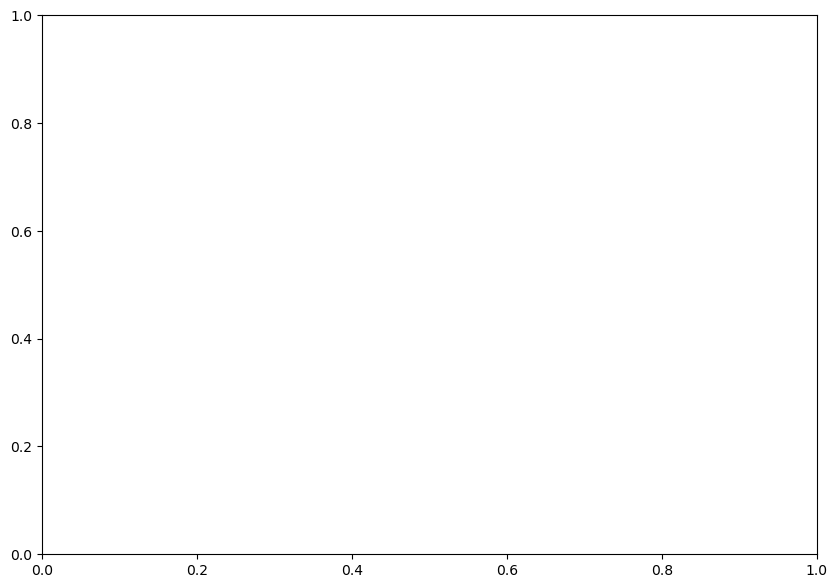

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms_corrected, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=40)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept differences')
plt.title('Top-1 matches using MD-finetuned vs True Subject SEEK distance')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")
plt.show()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_avg_corrected, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=40)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept avg accuracy')
plt.title('Top-1 matches using MD-finetuned vs True Subject SEEK distance')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")
plt.show()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_left_ear_corrected, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=40)
plt.xlabel('Cosine Similarity')
plt.ylabel('left ear Concept avg accuracy')
plt.title('Top-1 matches using MD-finetuned vs True Subject SEEK distance')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=40)
plt.xlabel('Cosine Similarity')
plt.ylabel('True Subject SEEK concept distance')
plt.title('Top-1 matches using MD-finetuned')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")
plt.show()